<font color="#0D9DF0"><h2><b>Trabalho Final - Série do Preço Futuro do Café</b></h2></font>

***

**Disciplina:** Séries Temporais — PUC Minas.   
**Professora:** Anaíle Mendes Rabelo.  
**Grupo:** Fernando Custódio, Leonardo Diniz, Lucas Rocha, Luciana Euzebio.

---

### 1- Buscando base de dados com API yfinance

In [ ]:
"""

Instalacao das dependencias:
    pip install yfinance pandas

Como rodar:
    - Em script normal (terminal):   python preco_do_cafe.py
    - Em notebook (Jupyter/VS Code): from preco_do_cafe import main
                                      df = main()
"""

# -- 1. IMPORTS ----------------------------------------------------------
from pathlib import Path         # caminhos de arquivo multiplataforma
import pandas as pd              # manipulacao e exportacao dos dados
import yfinance as yf            # acesso a series historicas do Yahoo Finance
import matplotlib.pyplot as plt  # biblioreca para criação de gráficos


In [3]:
# -- 2. CONFIGURACAO ------------------------------------------------------
OUTPUT_DIR = Path("dados_agro")
OUTPUT_DIR.mkdir(exist_ok=True)

# Quantos anos de historico buscar.
ANOS_HISTORICO = 4

# Ticker do contrato futuro de cafe arabica na ICE (Yahoo Finance).
# Cotado em US cents/lb (centavos de dolar por libra-peso).
TICKER_CAFE = "KC=F"


# -- 3. CALCULAR A DATA DE INICIO -----------------------------------------
def data_inicio(anos: int) -> str:
    """
    Calcula a data de `anos` atras a partir de hoje, no formato
    'AAAA-MM-DD' esperado pelo parametro `start` do yfinance.
    """
    hoje = pd.Timestamp.today()
    inicio = hoje - pd.DateOffset(years=anos)
    return inicio.strftime("%Y-%m-%d")



In [4]:
# -- 4. FUNCAO DE DOWNLOAD -------------------------------------------------
def baixar_preco_cafe(anos: int = ANOS_HISTORICO) -> pd.DataFrame:
    """
    Busca a serie diaria de preco do cafe (futuro ICE, ticker KC=F) para
    os ultimos `anos` anos e retorna um DataFrame do pandas com os dados.

    Diferente da versao anterior (baseada em agrobr/cepea), o yfinance
    nao precisa de await/asyncio: a chamada e sincrona.
    """
    inicio = data_inicio(anos)
    print(f"Baixando preco diario do cafe ({TICKER_CAFE}) desde {inicio}...")

    ticker = yf.Ticker(TICKER_CAFE)
    try:
        df = ticker.history(start=inicio, interval="1d", auto_adjust=False)
    except Exception as e:
        raise RuntimeError(
            "Falha ao consultar o Yahoo Finance (rede indisponivel, proxy "
            "bloqueando o dominio, ou instabilidade temporaria do servico). "
            f"Erro original: {e}"
        ) from e

    if df.empty:
        raise RuntimeError(
            "Nao foi possivel obter dados do Yahoo Finance para "
            f"'{TICKER_CAFE}'. Verifique a conexao com a internet, se o "
            "ticker ainda e valido e se o pacote yfinance esta atualizado "
            "('pip install -U yfinance')."
        )

    # Organiza e traduz as colunas para um formato mais claro em pt-BR.
    df = df.reset_index()
    df = df.rename(columns={
        "Date": "data",
        "Open": "abertura",
        "High": "maxima",
        "Low": "minima",
        "Close": "fechamento",
        "Volume": "volume",
    })
    df["data"] = pd.to_datetime(df["data"]).dt.tz_localize(None).dt.date
    df["produto"] = "cafe_arabica_futuro"
    df["unidade"] = "USD cents/lb"
    df["fonte"] = "Yahoo Finance (ticker KC=F, futuro ICE)"

    colunas = ["data", "abertura", "maxima", "minima", "fechamento", "volume",
               "produto", "unidade", "fonte"]
    colunas = [c for c in colunas if c in df.columns]
    df = df[colunas].sort_values("data").reset_index(drop=True)

    caminho = OUTPUT_DIR / "preco_cafe_ice_4anos.csv"
    df.to_csv(caminho, index=False, encoding="utf-8-sig")
    print(f"  OK -> {caminho} ({len(df)} linhas, {len(df.columns)} colunas)")

    return df



In [5]:
# -- 5. FUNCAO PRINCIPAL ----------------------------------------------------
def main() -> pd.DataFrame:
    df = baixar_preco_cafe()
    print("\nPrevia dos dados:")
    print(df.head())
    print("...")
    print(df.tail())
    return df



In [6]:
await main()

Baixando preco diario do cafe (KC=F) desde 2022-08-27...
  OK -> dados_agro\preco_cafe_ice_4anos.csv (1006 linhas, 9 colunas)

Previa dos dados:
         data    abertura      maxima      minima  fechamento  volume  \
0  2022-08-29  240.550003  240.550003  240.550003  240.500000       1   
1  2022-08-30  238.750000  241.750000  238.750000  239.149994      14   
2  2022-08-31  240.750000  240.750000  239.649994  239.100006      12   
3  2022-09-01  238.550003  238.550003  236.600006  236.350006       6   
4  2022-09-02  236.899994  237.550003  232.300003  232.649994       7   

               produto       unidade                                    fonte  
0  cafe_arabica_futuro  USD cents/lb  Yahoo Finance (ticker KC=F, futuro ICE)  
1  cafe_arabica_futuro  USD cents/lb  Yahoo Finance (ticker KC=F, futuro ICE)  
2  cafe_arabica_futuro  USD cents/lb  Yahoo Finance (ticker KC=F, futuro ICE)  
3  cafe_arabica_futuro  USD cents/lb  Yahoo Finance (ticker KC=F, futuro ICE)  
4  cafe_arabica_

TypeError: 'DataFrame' object can't be awaited

### 2- Contextualizando o problema a ser resolvido

O café é a segunda bebida mais consumida no mundo (perdendo somente para água), sendo uma das commodities agrícolas mais importantes da economia brasileira. O Brasil é, há décadas, o maior produtor e o maior exportador de café do mundo, respondendo por aproximadamente 38% da produção mundial segundo dados do USDA (Departamento de Agricultura dos Estados Unidos), à frente de Vietnã e Colômbia (AGÊNCIA MG, 2026). Minas Gerais segue sendo responsável por 44% da produção nacional. Em 2025, o país exportou mais de 40 milhões de sacas de 60 kg, gerando uma receita recorde de aproximadamente US$ 15,5 bilhões em divisas.

Devido a sua importância na economia, compreender e antecipar o comportamento do seu preço trata-se de uma questão com impacto direto sobre produtores rurais, cooperativas, indústria de torrefação, exportadores e sobre a própria política econômica regional e nacional. Antecipar seu comportamento auxilia na tomada de decisões para investimentos no setor, busca de recursos em bacos pelos produtores e incentivos a pesquisas.

Neste trabalho vamos analisar a série histórica do preço futuro de cafe arabica (ICE), cotado em USD/libra-peso (centavos de dolar por
libra-peso, "US cents/lb") para cria um modelo preditivo.

### 3- Processando de dados

3.1 - Carregando arquivos 

In [ ]:
caminho = "D:\OneDrive\Programação\GITHUB\Séries Temporais\dados_agro\preco_cafe_ice_4anos.csv"
df_cafe = pd.read_csv(caminho)

3.2- Primeiras análise

In [ ]:
print(f'A tabela possui {df_cafe.shape[0]} linhas e {df_cafe.shape[1]} colunas')
print('\n')
print(df_cafe.head())
print('\n')
print("*" * 100)
print('Informações sobre tipos de dados\n')
print(df_cafe.info())


A tabela possui 1006 linhas e 9 colunas


         data    abertura      maxima      minima  fechamento  volume  \
0  2022-08-29  240.550003  240.550003  240.550003  240.500000       1   
1  2022-08-30  238.750000  241.750000  238.750000  239.149994      14   
2  2022-08-31  240.750000  240.750000  239.649994  239.100006      12   
3  2022-09-01  238.550003  238.550003  236.600006  236.350006       6   
4  2022-09-02  236.899994  237.550003  232.300003  232.649994       7   

               produto       unidade                                    fonte  
0  cafe_arabica_futuro  USD cents/lb  Yahoo Finance (ticker KC=F, futuro ICE)  
1  cafe_arabica_futuro  USD cents/lb  Yahoo Finance (ticker KC=F, futuro ICE)  
2  cafe_arabica_futuro  USD cents/lb  Yahoo Finance (ticker KC=F, futuro ICE)  
3  cafe_arabica_futuro  USD cents/lb  Yahoo Finance (ticker KC=F, futuro ICE)  
4  cafe_arabica_futuro  USD cents/lb  Yahoo Finance (ticker KC=F, futuro ICE)  


*************************************

In [13]:
print('Resumo estatístico\n')
print(df_cafe.describe())

Resumo estatístico

          abertura       maxima       minima   fechamento        volume
count  1006.000000  1006.000000  1006.000000  1006.000000   1006.000000
mean    261.135487   264.619582   257.884792   261.113916  11082.801193
std      82.711093    83.985861    81.503449    82.707442  10818.266903
min     143.899994   146.250000   142.050003   143.899994      0.000000
25%     185.887505   188.012501   184.512501   185.575001     26.500000
50%     247.050003   249.449997   244.449997   246.675003  11342.000000
75%     330.512489   333.750008   324.337502   328.562508  19118.000000
max     435.399994   440.850006   424.049988   438.899994  49022.000000


3.3- Visão gráfica e análise de quebras

In [12]:
# -- 6. GRAFICO -------------------------------------------------------------
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Paleta e specs de uma serie temporal unica (linha fina, sem legenda --
# um unico titulo ja identifica o que esta plotado).
COR_LINHA = "#2a78d6"        # azul (cor padrao para serie unica)
COR_GRADE = "#e1e0d9"        # cinza claro, hairline (so no eixo Y)
COR_EIXO = "#c3c2b7"         # cinza para spines/baseline
COR_TEXTO_PRIM = "#0b0b0b"   # tinta primaria (titulo)
COR_TEXTO_SEC = "#52514e"    # tinta secundaria (labels dos eixos)
COR_TEXTO_MUTED = "#898781"  # tinta apagada (ticks)
COR_SUPERFICIE = "#fcfcfb"   # fundo do grafico


def plotar_preco_cafe(df: pd.DataFrame, salvar: bool = True) -> None:
    """
    Gera um grafico de linha do preco diario de fechamento do cafe
    (coluna 'fechamento', em US cents/lb) ao longo do periodo baixado.
    """
    df_plot = df.copy()
    df_plot["data"] = pd.to_datetime(df_plot["data"])

    fig, ax = plt.subplots(figsize=(11, 4.5), facecolor=COR_SUPERFICIE)
    ax.set_facecolor(COR_SUPERFICIE)

    ax.plot(
        df_plot["data"], df_plot["fechamento"],
        color=COR_LINHA, linewidth=1.6,
        solid_capstyle="round", solid_joinstyle="round",
    )

    ax.set_title(
        f"Preco diario do cafe ({TICKER_CAFE}, futuro ICE) "
        f"- ultimos {ANOS_HISTORICO} anos",
        color=COR_TEXTO_PRIM, fontsize=13, fontweight="bold", pad=12,
    )
    ax.set_xlabel("Data", color=COR_TEXTO_SEC)
    ax.set_ylabel("US cents / lb", color=COR_TEXTO_SEC)

    # So gradeado horizontal (hairline) -- reduz ruido visual numa serie
    # diaria longa; o eixo X ja fica marcado pelos ticks de data.
    ax.grid(True, axis="y", color=COR_GRADE, linewidth=0.8)
    ax.set_axisbelow(True)

    for spine in ("top", "right"):
        ax.spines[spine].set_visible(False)
    for spine in ("left", "bottom"):
        ax.spines[spine].set_color(COR_EIXO)

    ax.tick_params(colors=COR_TEXTO_MUTED, labelsize=9)
    locator = mdates.AutoDateLocator()
    ax.xaxis.set_major_locator(locator)
    ax.xaxis.set_major_formatter(mdates.ConciseDateFormatter(locator))

    fig.tight_layout()

    if salvar:
        caminho_grafico = OUTPUT_DIR / "grafico_preco_cafe_ice_4anos.png"
        fig.savefig(caminho_grafico, dpi=150, facecolor=fig.get_facecolor())
        print(f"Grafico salvo em: {caminho_grafico}")

    plt.show()

Grafico salvo em: dados_agro\grafico_preco_cafe_ice_4anos.png


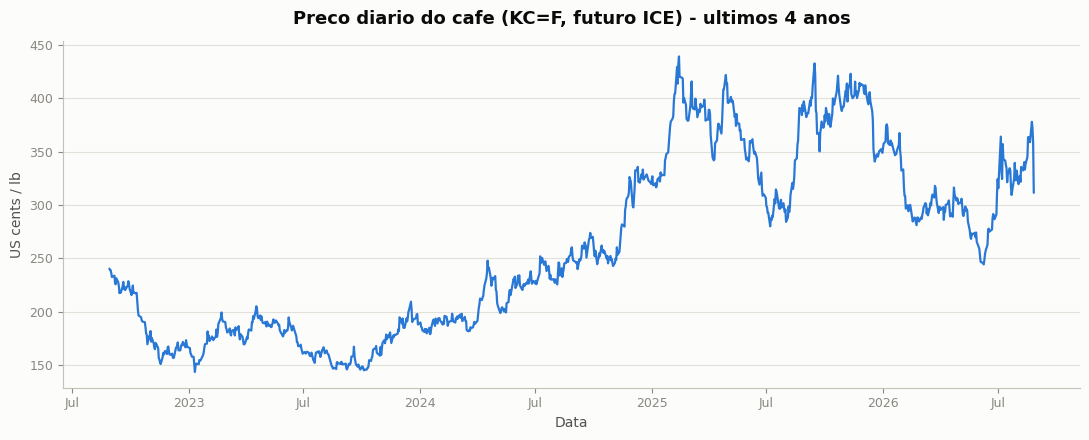

In [13]:
plotar_preco_cafe(df_cafe)

In [ ]:
# Verificando valores nulos
df_cafe.isna().sum()

data          0
abertura      0
maxima        0
minima        0
fechamento    0
volume        0
produto       0
unidade       0
fonte         0
dtype: int64

In [20]:

# Define o período
inicio = '2022-08-27'
fim = '2026-08-27'

# Filtra o período
df_periodo = df_cafe[
    (df_cafe['data'] >= inicio) &
    (df_cafe['data'] <= fim)
]

# Quantidade de dias corridos no período
dias_periodo = (
    pd.to_datetime(fim) - pd.to_datetime(inicio)
).days + 1

# Quantidade de dias com fechamento
dias_com_valor = df_periodo['fechamento'].notna().sum()

# Diferença
gaps = dias_periodo - dias_com_valor

print(f'Dias no período: {dias_periodo}')
print(f'Dias com fechamento: {dias_com_valor}')
print(f'Diferença: {gaps}')

Dias no período: 1462
Dias com fechamento: 1006
Diferença: 456


Fazendo uma análise usando o excel, verificamos que tivemos 417 sábados e domingos, dias em que não temos pregrão. Isso sem considera os feriádos no período. Também não temos valores nulos na nossa série, como datas em que não tivemos algum valor.  
Podemos concluir que a sério não tem 'gas' de dados que possam prejudicar nossas análise.

3.3- Avaliação de Outliers

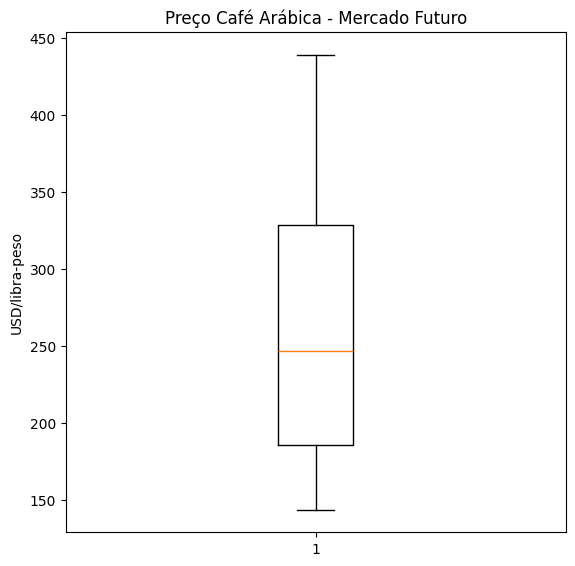

In [19]:
area = plt.figure(figsize=(5, 5))
grafico = area.add_axes([0, 0, 1, 1])

grafico.boxplot(df_cafe['fechamento'])

grafico.set_title('Preço Café Arábica - Mercado Futuro')
grafico.set_ylabel('USD/libra-peso')
# grafico.set_yscale('log')

plt.show()

No gráfico se observou que não temos Outliers, o que é esperado por ser um série com tendêndencia, não estacinária.


### 4- Analise de variáveis - análise descritiva, decomposição de componentes

### 5- análise de aucorrelação

### 6- validação de pressupostos, verificação de estacionaridade e normalidade.

### 7- rodar o modelo , que melhor se ajusta. 

### 8- interpretação da saída (métricas de avaliação e coeficientes)